# 03 — Corrélation implicite, premium & signal (Semaine 2)

**Objectif.** Construire la série quotidienne de $\rho_{\text{implied}}$ (inversion one-factor, DMV éq. 2),
les deux séries réalisées window-matchées, puis valider empiriquement la thèse du projet :
*le marché surpaie la corrélation* (premium > 0 en moyenne).

**Décisions actées (README §5, §5.1, §8) :**
- $\sigma$ = **IV ATM 91j** (instrument-consistency ; biais conservateur vs MFIV)
- **Renormalisation quotidienne** des poids sur les titres avec IV disponible + plancher 90/100 (`n_names`)
- $\rho_{\text{implied}}$ stocké **brut** (pas de clipping) + compteurs de violations
- `rho_forward(t) = rho_trailing(t+63 j ouvrés)` (window-matching DMV) ; `premium` = validation ex-post ; `signal` = tradeable ex-ante

$$\rho_{\text{implied}}(t) = \frac{\sigma_{I,t}^2 - \sum_i \hat w_i^2\sigma_{i,t}^2}{\big(\sum_i \hat w_i\sigma_{i,t}\big)^2 - \sum_i \hat w_i^2\sigma_{i,t}^2},\qquad \hat w_i = \frac{w_i}{\sum_{j\in A(t)} w_j}$$

où $A(t)$ = titres avec IV valide le jour $t$. Même fonctionnelle que $\bar\rho_{\text{realised}}$ (option B) → spread pomme-à-pomme.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
P = ROOT / "data" / "processed"

iv_index = pd.read_parquet(P / "iv_index.parquet")
iv_comp  = pd.read_parquet(P / "iv_components.parquet")
weights  = pd.read_parquet(P / "weights.parquet")
rcorr    = pd.read_parquet(P / "realized_corr.parquet")

# cosmétique S1 : identifiants en Int64 partout
iv_comp["secid"]  = iv_comp["secid"].astype("Int64")
iv_comp["permno"] = iv_comp["permno"].astype("Int64")
weights["permno"] = weights["permno"].astype("Int64")

for df in (iv_index, iv_comp, weights, rcorr):
    for c in ("date", "rebalance_date"):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c])

print(f"iv_index {iv_index.shape} | iv_comp {iv_comp.shape} | weights {weights.shape} | rcorr {rcorr.shape}")

iv_index (7281, 4) | iv_comp (717221, 5) | weights (11600, 6) | rcorr (7221, 3)


## Calcul de $\rho_{\text{implied}}$

Avec $S_1 = \sum_{i\in A} \hat w_i\sigma_i$ et $S_2 = \sum_{i\in A} \hat w_i^2\sigma_i^2$, le dénominateur
vaut $S_1^2 - S_2 = \sum_{i\neq j}\hat w_i\hat w_j\sigma_i\sigma_j$. La renormalisation est algébrique :
$S_1 = \frac{\sum w_i\sigma_i}{\sum w_i}$ et $S_2 = \frac{\sum w_i^2\sigma_i^2}{(\sum w_i)^2}$ (sommes sur $A(t)$),
donc tout se calcule en un `groupby(date)` sans boucle.

In [2]:
m = iv_comp.merge(weights[["rebalance_date", "permno", "weight"]],
                  on=["rebalance_date", "permno"], how="left", validate="m:1")
assert m["weight"].notna().all(), "permno sans poids — incohérence univers/IV"

valid = m.dropna(subset=["iv_atm"]).copy()
valid["w_sig"]   = valid["weight"] * valid["iv_atm"]
valid["w2_sig2"] = valid["weight"]**2 * valid["iv_atm"]**2

g = valid.groupby("date").agg(
    w_sum=("weight", "sum"),
    s1_raw=("w_sig", "sum"),
    s2_raw=("w2_sig2", "sum"),
    n_names=("weight", "size"),
)
S1 = g["s1_raw"] / g["w_sum"]          # somme des poids renormalisés × IV
S2 = g["s2_raw"] / g["w_sum"]**2       # terme diagonal renormalisé

sig_I = iv_index.set_index("date")["iv_atm"].reindex(g.index)

rho_implied = (sig_I**2 - S2) / (S1**2 - S2)
rho_implied[g["n_names"] < 90] = np.nan   # plancher de couverture (garde-fou, jamais atteint)

out = pd.DataFrame({"rho_implied": rho_implied, "n_names": g["n_names"]})
out["rho_implied"].describe()

count      7221.0
mean     0.426321
std      0.132345
min      0.120059
25%      0.342467
50%      0.426349
75%      0.501879
max       0.91346
Name: rho_implied, dtype: Float64

In [3]:
# Diagnostics : bornes (stockage brut, pas de clipping) + couverture
viol_hi    = int((out["rho_implied"] > 1).sum())
viol_lo    = int((out["rho_implied"] < 0).sum())
floor_hits = int((g["n_names"] < 90).sum())
print(f"jours: {len(out)} | NaN rho_implied: {int(out['rho_implied'].isna().sum())}")
print(f"violations rho>1: {viol_hi} | rho<0: {viol_lo} | jours sous plancher (<90): {floor_hits}")
print(f"couverture n_names — min: {int(out['n_names'].min())}, mediane: {int(out['n_names'].median())}, max: {int(out['n_names'].max())}")

jours: 7221 | NaN rho_implied: 0
violations rho>1: 0 | rho<0: 0 | jours sous plancher (<90): 0
couverture n_names — min: 91, mediane: 99, max: 100


## Les deux séries réalisées + premium & signal

- `rho_trailing(t)` : $\bar\rho$ réalisée sur $[t-63, t]$ (déjà dans `realized_corr.parquet`).
- `rho_forward(t) = rho_trailing(t+63)` : décalage de 63 **lignes** du calendrier maître.

*Caveats documentés :* le décalage en lignes traverse le trou OptionMetrics d'août 2020 (fenêtre calendaire
légèrement plus longue autour du gap) ; au passage d'un trimestre, le trailing en $t+63$ utilise les poids
du rebalancement couvrant $t+63$ (second ordre pour la validation).

In [4]:
spine = rcorr.set_index("date").sort_index()          # calendrier maître (7221 jours)
sig = out.join(spine[["rho_bar"]], how="right").sort_index()
sig = sig.rename(columns={"rho_bar": "rho_trailing"})
sig["rho_forward"] = sig["rho_trailing"].shift(-63)
sig["premium"] = sig["rho_implied"] - sig["rho_forward"]
sig["signal"]  = sig["rho_implied"] - sig["rho_trailing"]
cols = ["rho_implied", "rho_trailing", "rho_forward", "premium", "signal"]
sig[cols] = sig[cols].astype("float64")   # neutralise les dtypes nullables (statsmodels/matplotlib)
sig[cols].describe().round(4)

,rho_implied,rho_trailing,rho_forward,premium,signal
count,7221.0000,7220.0000,7157.0000,7157.0000,7220.0000
mean,0.4263,0.3481,0.3489,0.0794,0.0782
std,0.1323,0.1305,0.1308,0.1370,0.0946
min,0.1201,0.0792,0.0792,-0.4579,-0.2556
25%,0.3425,0.2587,0.2589,-0.0006,0.0195
50%,0.4263,0.3260,0.3273,0.0960,0.0844
75%,0.5019,0.4199,0.4212,0.1653,0.1423
max,0.9135,0.8274,0.8274,0.5296,0.4285


In [5]:
# Stats de validation — Newey–West (63 lags, fenêtres chevauchantes)
import statsmodels.api as sm

def nw_mean(series, lags=63):
    s = series.dropna().astype("float64")   # les dtypes nullables (Float64) cassent statsmodels
    res = sm.OLS(s.to_numpy(), np.ones((len(s), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return s.mean(), float(res.tvalues[0]), len(s)

print(f"rho_implied moyen : {sig['rho_implied'].mean():.4f} | rho_forward moyen : {sig['rho_forward'].mean():.4f} | rho_trailing moyen : {sig['rho_trailing'].mean():.4f}")
print()
for name in ("premium", "signal"):
    s = sig[name].dropna()
    mu, t, n = nw_mean(sig[name])
    print(f"{name:8s}: moyenne = {mu:+.4f} | t-NW(63) = {t:5.2f} | % jours > 0 = {(s > 0).mean():.1%} | n = {n}")

rho_implied moyen : 0.4263 | rho_forward moyen : 0.3489 | rho_trailing moyen : 0.3481

premium : moyenne = +0.0794 | t-NW(63) =  7.40 | % jours > 0 = 74.9% | n = 7157
signal  : moyenne = +0.0782 | t-NW(63) = 10.62 | % jours > 0 = 80.3% | n = 7220


In [6]:
# Sous-périodes (aperçu S5 : compression post-2003 ? — limits-to-arbitrage)
eras = [("1996-2003", "1996", "2003"), ("2004-2007", "2004", "2007"),
        ("2008-2012", "2008", "2012"), ("2013-2019", "2013", "2019"),
        ("2020-2024", "2020", "2024")]
rows = []
for label, a, b in eras:
    s = sig.loc[a:b, "premium"]
    mu, t, n = nw_mean(s)
    rows.append((label, round(mu, 4), round(t, 2), f"{(s.dropna() > 0).mean():.0%}", n))
pd.DataFrame(rows, columns=["période", "premium moyen", "t-NW(63)", "% jours > 0", "n"]).set_index("période")

,premium moyen,t-NW(63),% jours > 0,n
période,,,,
1996-2003,0.0845,4.87,73%,1953
2004-2007,0.0781,4.06,81%,1006
2008-2012,0.1353,4.25,83%,1259
2013-2019,0.0688,3.29,75%,1761
2020-2024,0.0284,1.19,63%,1178


## Graphe de validation — l'implicite au-dessus du réalisé forward

Panneau haut : $\rho_{\text{implied}}$ vs $\rho_{\text{realised}}^{\text{fwd}}$ (moyennes glissantes 21 j pour la lisibilité).
Panneau bas : premium window-matché (moyenne glissante 63 j) — la thèse = série en moyenne au-dessus de zéro.

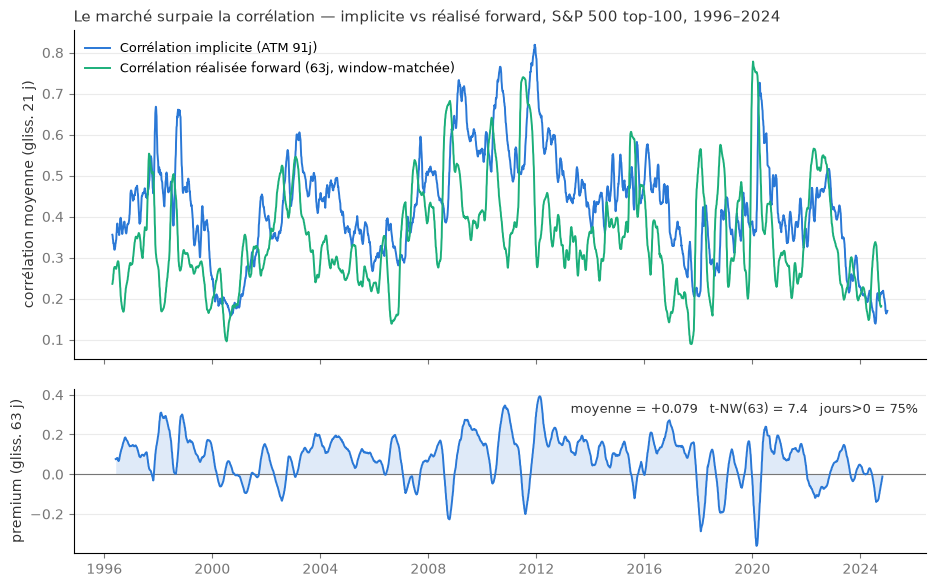

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

C_IMP, C_FWD, INK, MUTED = "#2a78d6", "#1baf7a", "#333333", "#767676"

imp21 = sig["rho_implied"].rolling(21, min_periods=15).mean()
fwd21 = sig["rho_forward"].rolling(21, min_periods=15).mean()
prem63 = sig["premium"].rolling(63, min_periods=45).mean()
mu, t, n = nw_mean(sig["premium"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.8), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12})

ax1.plot(imp21.index, imp21, color=C_IMP, lw=1.4, label="Corrélation implicite (ATM 91j)")
ax1.plot(fwd21.index, fwd21, color=C_FWD, lw=1.4, label="Corrélation réalisée forward (63j, window-matchée)")
ax1.set_ylabel("corrélation moyenne (gliss. 21 j)", color=INK)
ax1.legend(loc="upper left", frameon=False, fontsize=9)
ax1.set_title("Le marché surpaie la corrélation — implicite vs réalisé forward, S&P 500 top-100, 1996–2024",
              loc="left", fontsize=11, color=INK)

ax2.axhline(0, color=MUTED, lw=0.8)
ax2.plot(prem63.index, prem63, color=C_IMP, lw=1.4)
ax2.fill_between(prem63.index, 0, prem63, color=C_IMP, alpha=0.15, linewidth=0)
ax2.set_ylabel("premium (gliss. 63 j)", color=INK)
ax2.annotate(f"moyenne = {mu:+.3f}   t-NW(63) = {t:.1f}   jours>0 = {(sig['premium'].dropna()>0).mean():.0%}",
             xy=(0.99, 0.92), xycoords="axes fraction", ha="right", va="top",
             fontsize=9, color=INK)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(colors=MUTED)
ax2.xaxis.set_major_locator(mdates.YearLocator(4))

(ROOT / "results").mkdir(exist_ok=True)
fig.savefig(ROOT / "results" / "figures" / "fig_crp_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## Constats & prochaine étape

À vérifier dans les sorties ci-dessus :
1. $\rho_{\text{implied}} \in [0,1]$ partout (violations = 0 attendu, cohérent avec la QA : IV panier > IV indice tous les jours) ;
2. premium **positif en moyenne** avec t-NW significatif → le CRP existe sur 1996–2024 (validation de la thèse) ;
3. signal positif en moyenne lui aussi (le proxy trailing hérite de la prime) ;
4. sous-périodes : premier aperçu de la question S5 (compression post-2003 ?).

**Prochaine étape :** promotion en `src/dispersion/signal/implied_corr.py` + écriture de `signal.parquet`.